# Self-check Reliability 
### inter-rater reliability is a quantitative way to assess how similar someone's behavioral scoring is to anothers. When training new students on behavioral scoring, ideally we want to observe a realibility score of >0.90 on all of the behaviors of interest. 

### this script is to allow for students who have completed the reliability scoring to 
### (1) evaluate if their output files are in the correct format
### (2) determine their inter-rater reliability for behavioral scoring 

## *Prior to running this script, you should have scored the original reliability 1-6 videos for allogrooming, allolicking, self-licking and selfgrooming according to the* 

### 1. run this code to first import the necessary libraries we will need to do this analysis

In [1]:
#Import necessary libraries
#you may need to install some of these packages if you haven't already
%pip install pingouin


import pandas as pd
import numpy as np
import pingouin as pg
from sklearn.metrics import cohen_kappa_score
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


### 2. Define the path to your own server folder --> you will need to copy and paste the path to your server folder here, if you don't know what a pathname is or how to copy it for your operating system, please google it.  

In [11]:
# define the folder path to YOUR OWN server folder, 
folder_path = r"/Volumes/mkeisler"
#Input initials of the user to compare all other scores against
initial_1 = "PRB" 
standard_path = r"/Volumes/Lab/Reliability/socialTransferBehaviors/data/standard"

# create a folder with the folder_path called reliability_results if it doesn't already exist
results_folder = os.path.join(folder_path, "reliability_results")
if not os.path.exists(results_folder):
    os.makedirs(results_folder)
results_folder_path = os.path.join(folder_path, "reliability_results")

#create a folder within the results_folder called norm_relaibility 
norm_reliability_folder = os.path.join(results_folder_path, "norm_reliability")
if not os.path.exists(norm_reliability_folder):
    os.makedirs(norm_reliability_folder)
norm_reliability_folder_path = os.path.join(results_folder_path, "norm_reliability")    

# create a folder within the results_folder called huddling_reliability 
huddling_reliability_folder = os.path.join(results_folder_path, "huddling_reliability")
if not os.path.exists(huddling_reliability_folder):
    os.makedirs(huddling_reliability_folder)
huddling_reliability_folder_path = os.path.join(results_folder_path, "huddling_reliability")    



### 1. open your server folder
### 2. identify the newly created folder 'reliability_results', open it 
### 3. identify the newly created subfolder 'norm_reliability', open it and paste in you original 6 reliability .csv files 
### 3. identify the newly created subfolder 'huddling_reliability', open it and paste in your 6 huddling reliability .csv files 

### run the following cell to determine if your files are in the correct format 

In [28]:
#get a list of the files in the norm_reliability_folder
norm_files = os.listdir(norm_reliability_folder_path)
norm_files = [f for f in norm_files if f.endswith('.csv')]

# determine if the files are named correctly with the format reliability#_inis=initials.csv, where # is a number from 1 to 6
norm_pattern = r"reliability[1-6]_[A-Z]{2,3}\.csv"
for file in norm_files:
    if not re.fullmatch(norm_pattern, file):
        print(
            f"File {file} is not named correctly. Please rename it to match the format reliability#_inis=initials.csv, where # is a number from 1 to 6 and initials are 2 or 3 capital letters."
        )

#get a list of the files in the huddling_reliability_folder
huddling_files = os.listdir(huddling_reliability_folder_path)
huddling_files = [f for f in huddling_files if f.endswith('.csv')]

# determine if the files are named correctly with the format huddling_reliability#_inis=initials.csv, where # is a number from 1 to 6
huddling_pattern = r"huddling_reliability[1-6]_[A-Z]{2,3}\.csv"
for file in huddling_files:
    if not re.fullmatch(huddling_pattern, file):
        print(
            f"File {file} is not named correctly. Please rename it to match the format huddling_reliability#_inis=initials.csv, where # is a number from 1 to 6 and initials are 2 or 3 capital letters."
        )

# if all files are named correctly, print a message confirming this 
if all(re.fullmatch(norm_pattern, file) for file in norm_files) and all(
    re.fullmatch(huddling_pattern, file) for file in huddling_files
):
    print("All files are named correctly. Proceeding with reliability analysis.")



All files are named correctly. Proceeding with reliability analysis.


### Run to determine if files are formatted correctly

In [29]:

def validate_csv_structure(file_path):
    try:
        # Read as comma-separated
        df = pd.read_csv(file_path, header=None)

        # Drop completely empty columns
        df = df.dropna(axis=1, how='all')

        for i, row in df.iterrows():
            if len(row) != 4:
                return f"Row {i+1} does not have 4 columns after cleaning (got {len(row)})"

            behavior, start, end, duration = row

            # Ensure behavior is string
            if not isinstance(behavior, str):
                return f"Row {i+1}: behavior is not a string"

            # Ensure numeric values
            try:
                float(start)
                float(end)
                float(duration)
            except ValueError:
                return f"Row {i+1}: start/end/duration must be numeric"

        return None

    except Exception as e:
        return f"Could not read file: {e}"
# Run it
validate_folder(norm_reliability_folder_path)
validate_folder(huddling_reliability_folder_path)


✅ reliability1_MNK.csv is correctly formatted
✅ reliability2_MNK.csv is correctly formatted
✅ reliability3_MNK.csv is correctly formatted
✅ reliability4_MNK.csv is correctly formatted
✅ reliability5_MNK.csv is correctly formatted
✅ reliability6_MNK.csv is correctly formatted
✅ huddling_reliability1_MNK.csv is correctly formatted
✅ huddling_reliability2_MNK.csv is correctly formatted
✅ huddling_reliability3_MNK.csv is correctly formatted
✅ huddling_reliability4_MNK.csv is correctly formatted
✅ huddling_reliability5_MNK.csv is correctly formatted
✅ huddling_reliability6_MNK.csv is correctly formatted


In [31]:
import time

converted_files = []
skipped_files = []
failed_files = []

target_folders = [norm_reliability_folder_path, huddling_reliability_folder_path]

for target_folder in target_folders:
    for filename in os.listdir(target_folder):
        if not filename.lower().endswith('.csv'):
            continue

        file_path = os.path.join(target_folder, filename)
        temp_path = f"{file_path}.utf8.tmp"

        try:
            # Detect UTF-16 files using BOM bytes.
            with open(file_path, 'rb') as f:
                bom = f.read(2)

            if bom not in (b'\xff\xfe', b'\xfe\xff'):
                skipped_files.append((target_folder, filename))
                continue

            for attempt in range(3):
                try:
                    with open(file_path, 'r', encoding='utf-16', newline='') as f:
                        content = f.read()

                    with open(temp_path, 'w', encoding='utf-8', newline='') as f:
                        f.write(content)

                    os.replace(temp_path, file_path)
                    converted_files.append((target_folder, filename))
                    break
                except BlockingIOError:
                    # OneDrive/network paths can be briefly locked during writes.
                    if attempt == 2:
                        raise
                    time.sleep(0.3 * (attempt + 1))

        except Exception as e:
            if os.path.exists(temp_path):
                os.remove(temp_path)
            failed_files.append((target_folder, filename, str(e)))

print(f"Converted {len(converted_files)} file(s) from UTF-16 to UTF-8.")
if converted_files:
    for folder, name in sorted(converted_files):
        print(f"  converted: {os.path.basename(folder)}/{name}")

print(f"Skipped {len(skipped_files)} file(s) already UTF-8 or non-UTF-16.")
if skipped_files:
    for folder, name in sorted(skipped_files):
        print(f"  skipped: {os.path.basename(folder)}/{name}")

if failed_files:
    print(f"Failed on {len(failed_files)} file(s):")
    for folder, name, err in failed_files:
        print(f"  failed: {os.path.basename(folder)}/{name} -> {err}")


Converted 0 file(s) from UTF-16 to UTF-8.
Skipped 12 file(s) already UTF-8 or non-UTF-16.
  skipped: huddling_reliability/huddling_reliability1_MNK.csv
  skipped: huddling_reliability/huddling_reliability2_MNK.csv
  skipped: huddling_reliability/huddling_reliability3_MNK.csv
  skipped: huddling_reliability/huddling_reliability4_MNK.csv
  skipped: huddling_reliability/huddling_reliability5_MNK.csv
  skipped: huddling_reliability/huddling_reliability6_MNK.csv
  skipped: norm_reliability/reliability1_MNK.csv
  skipped: norm_reliability/reliability2_MNK.csv
  skipped: norm_reliability/reliability3_MNK.csv
  skipped: norm_reliability/reliability4_MNK.csv
  skipped: norm_reliability/reliability5_MNK.csv
  skipped: norm_reliability/reliability6_MNK.csv


### if you files are not correctly formatted please go back and re-export your csv files in accordance to the ELAN protocol 

### Run to copy the standardized file into the same directory ask your .csv files 

In [12]:
#define path for standard files 
standard_files_path = r"/Volumes/Lab/Reliability/socialTransferBehaviors/data/standard"
import shutil

#copy standard files begining with "reliability" to norm_reliability_folder
for file in os.listdir(standard_files_path):
    if file.startswith("reliability") and file.endswith(".csv"):
        src = os.path.join(standard_files_path, file)
        dst = os.path.join(norm_reliability_folder_path, file)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        
        
# copy standard files begining with "huddling_reliability" to huddling_reliability_folder
for file in os.listdir(standard_files_path):
    if file.startswith("huddling_reliability") and file.endswith(".csv"):
        src = os.path.join(standard_files_path, file)
        dst = os.path.join(huddling_reliability_folder_path, file)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            

### Run to define all behaviors

In [13]:
#Create function to standardize behavior names
def standardize(x):
    '''
    Standardize behavior labels to canonical names.
    Removes spaces/punctuation and maps common variants/synonyms.
    '''
    label = str(x).strip().lower()
    label_cleaned = re.sub(r'[^a-zA-Z]', '', label)
    
    canonical_map = {
        # self-licking variants
        'selflicking': 'selflicking',
        'selflick': 'selflicking',
        'selflicks': 'selflicking',

        # self-grooming variants
        'selfgrooming': 'selfgrooming',
        'selfgroom': 'selfgrooming',
        'selfgrooms': 'selfgrooming',
        'autogrooming': 'selfgrooming',
        'autogroom': 'selfgrooming',

        # social grooming variants
        'allogrooming': 'allogrooming',
        'allogroom': 'allogrooming',
        'socialgrooming': 'allogrooming',

        # social licking variants
        'allolicking': 'allolicking',
        'allolick': 'allolicking',
        'sociallicking': 'allolicking',

        # huddling variants
        'huddling': 'huddling',
        'huddle': 'huddling',
    }
    
    if label_cleaned in canonical_map:
        return canonical_map[label_cleaned]
    
    # Fallback rules for unseen variants
    if label_cleaned.startswith('self') and 'groom' in label_cleaned:
        return 'selfgrooming'
    if label_cleaned.startswith('self') and 'lick' in label_cleaned:
        return 'selflicking'
    if 'groom' in label_cleaned and not label_cleaned.startswith('self'):
        return 'allogrooming'
    if 'lick' in label_cleaned and not label_cleaned.startswith('self'):
        return 'allolicking'
    
    # Keep unknown labels in cleaned form so they can still be inspected
    return label_cleaned

### Run pairwise comparison for reliability

In [20]:
# Create data frames from each csv and initiate pairwise ICC comparisons for both reliability folders
datasets = {
    'norm_reliability': {
        'folder': norm_reliability_folder_path,
        'behaviors': ['allogrooming', 'allolicking', 'selflicking', 'selfgrooming'],
    },
    'huddling_reliability': {
        'folder': huddling_reliability_folder_path,
        'behaviors': ['huddling'],
    },
}

all_outputs = {}

for dataset_name, config in datasets.items():
    folder_to_analyze = config['folder']
    behaviors = config['behaviors']

    # Dictionary to hold all data for this folder
    all_video_data = {}
    all_initials = set()

    for filename in os.listdir(folder_to_analyze):
        if not filename.endswith('.csv'):
            continue

        file_path = os.path.join(folder_to_analyze, filename)

        # Extract initials and video name from filename
        filename_parts = filename.replace('.csv', '').split('_')
        if len(filename_parts) < 2:
            continue

        initials = filename_parts[-1]
        video_name = '_'.join(filename_parts[:-1])
        all_initials.add(initials)

        # Turn current csv file into a data frame
        df = pd.read_csv(file_path, header=None)

        # Standardize behavior labels
        df[0] = df[0].apply(standardize)

        # Get total duration of each behavior (duration in column 4)
        d = dict(df.groupby(0).sum()[4])

        curr_vid_data = {}
        for key, value in d.items():
            curr_vid_data[f'{key}_{initials}'] = value

        if video_name not in all_video_data:
            all_video_data[video_name] = curr_vid_data
        else:
            all_video_data[video_name].update(curr_vid_data)

    if not all_video_data:
        print(f'No CSV files found for {dataset_name}.')
        all_outputs[dataset_name] = {}
        continue

    reliability_df = pd.DataFrame(all_video_data).T.sort_index().fillna(0)
    output = {}

    print(f'\n===== {dataset_name} =====')

    for behavior in behaviors:
        col = [c for c in reliability_df.columns if c.startswith(f'{behavior}_')]
        if not col:
            print(f'No columns found for behavior: {behavior}')
            output[behavior] = {}
            continue

        behavior_df = reliability_df[col].copy()
        behavior_df.columns = behavior_df.columns.str.split('_').str[-1]
        behavior_df = behavior_df.T.groupby(level=0).sum().T

        if initial_1 not in behavior_df.columns:
            print(f"Reference rater '{initial_1}' not found for behavior: {behavior}")
            output[behavior] = {}
            continue

        icc_results = {}
        for rater in behavior_df.columns:
            if rater == initial_1:
                continue

            temp_df = behavior_df[[initial_1, rater]].reset_index()
            temp_df = temp_df.melt(id_vars='index', var_name='Rater', value_name='Score')

            # Need at least 2 targets for ICC to be calculable
            if temp_df['index'].nunique() < 2:
                print(f'  Skipping {behavior} vs {rater}: not enough videos (need at least 2).')
                continue

            icc_result = pg.intraclass_corr(data=temp_df, targets='index', raters='Rater', ratings='Score')

            # Pingouin may label this as ICC2 or ICC(A,1) depending on version
            icc2_row = icc_result[icc_result['Type'].isin(['ICC2', 'ICC(A,1)'])]
            if icc2_row.empty:
                print(f'  ICC2 not available for {behavior} vs {rater}. Available types: {icc_result["Type"].tolist()}')
                continue
            icc_value = icc2_row['ICC'].values[0]
            icc_results[rater] = icc_value

        output[behavior] = icc_results

        if icc_results:
            icc_df = pd.DataFrame.from_dict(
                icc_results,
                orient='index',
                columns=[f'ICC with {initial_1} for {behavior}'],
            ).reset_index()
            print(icc_df)
        else:
            print(f'  No ICC results computed for {behavior}.')

    all_outputs[dataset_name] = output

# Keep backward compatibility if downstream cells expect `output`
output = all_outputs.get('norm_reliability', {})


===== norm_reliability =====
  index  ICC with PRB for allogrooming
0   MNK                       0.973119
  index  ICC with PRB for allolicking
0   MNK                      0.994527
  index  ICC with PRB for selflicking
0   MNK                      0.944981
  index  ICC with PRB for selfgrooming
0   MNK                       0.984478

===== huddling_reliability =====
  index  ICC with PRB for huddling
0   MNK                   0.948815


In [ ]:
### Run this cell to produce a .png of the results 

Saved PNG to: /Volumes/mkeisler/reliability_results/ICC_behavior_table_PRB.png


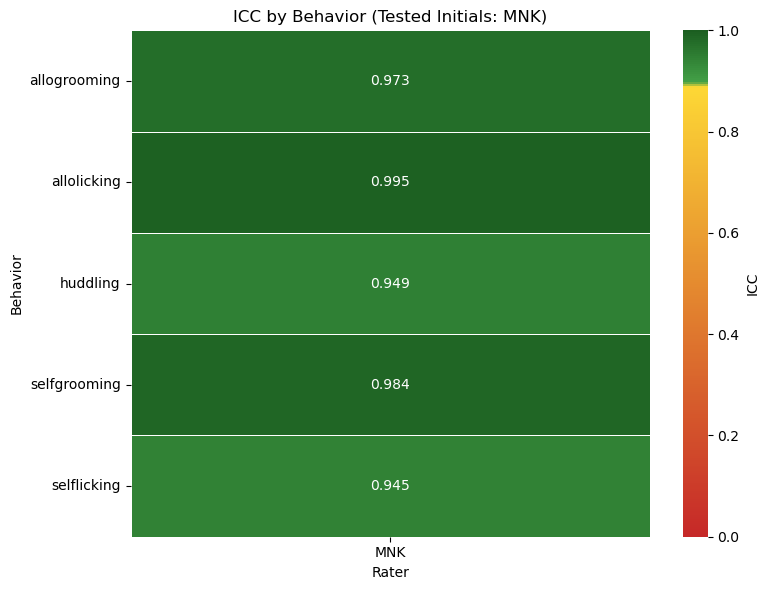

In [23]:
# Plot ICC table (behaviors x raters) and save as PNG
from matplotlib.colors import LinearSegmentedColormap, Normalize

icc_rows = {}
for dataset_name, behavior_dict in all_outputs.items():
    for behavior, rater_scores in behavior_dict.items():
        icc_rows[behavior] = rater_scores

icc_table = pd.DataFrame.from_dict(icc_rows, orient='index').sort_index()

if icc_table.empty:
    print('No ICC results available to plot. Run the ICC comparison cell first.')
else:
    # Order columns (raters) alphabetically for consistency
    icc_table = icc_table.reindex(sorted(icc_table.columns), axis=1)

    # Red -> Yellow -> Green with >= 0.90 in green zone
    icc_cmap = LinearSegmentedColormap.from_list(
        'icc_r2g_threshold',
        [
            (0.00, '#c62828'),  # red
            (0.89, '#fdd835'),  # yellow just below threshold
            (0.90, '#43a047'),  # green at threshold
            (1.00, '#1b5e20'),  # darker green
        ],
    )
    icc_norm = Normalize(vmin=0.0, vmax=1.0, clip=True)

    fig_width = max(8, 1.6 * len(icc_table.columns))
    fig_height = max(4, 0.8 * len(icc_table.index) + 2)

    tested_initials = ', '.join(icc_table.columns.tolist()) if len(icc_table.columns) else 'None'

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        icc_table,
        annot=True,
        fmt='.3f',
        cmap=icc_cmap,
        norm=icc_norm,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'ICC'},
    )
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)
    plt.title(f'ICC by Behavior (Tested Initials: {tested_initials})')
    plt.xlabel('Rater')
    plt.ylabel('Behavior')
    plt.tight_layout()

    icc_png_path = os.path.join(results_folder_path, f'ICC_behavior_table_{initial_1}.png')
    plt.savefig(icc_png_path, dpi=300, bbox_inches='tight')
    print(f'Saved PNG to: {icc_png_path}')
    plt.show()